(mmm_dims_migration_guide)=
# MMM Dims Migration Guide

This guide covers the changes introduced by the migration of PyMC-Marketing's MMM internals to [`pymc.dims`](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/dims_module.html) and PyTensor's [`xtensor`](https://pytensor.readthedocs.io/en/latest/library/xtensor/index.html) system.

The impact depends on how you use the library:

- **High-level users** (standard model fitting, prediction, budget optimization): minimal changes.
- **Low-level users** (custom transformations, extensions, direct model building): significant API changes.


In [1]:
import warnings

import numpy as np
import pandas as pd

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.multidimensional import MMM

## High-Level Users: Prior Array Parameters

If you use `MMM` through its standard API (fit, predict, budget optimization), **nothing changes** in your workflow.

The one thing you may notice is a new warning when passing raw arrays or lists as prior parameters. Previously, a value like `mu=[2, 1]` was passed through without any dimension information. Now, the system needs to know **which dimension** the array corresponds to.

By default, array parameters are assumed to map to the **rightmost dimension** of the prior's `dims`. For instance, when the MMM sets `dims=("channel",)` on your saturation beta prior internally, a 1D array is assumed to be along `"channel"`. This works, but emits a warning encouraging you to be explicit.

In [2]:
from pymc_extras.prior import Prior

# Per-channel saturation beta: raw list triggers a warning at build_model time
saturation_beta_prior = Prior("Gamma", mu=[2, 1], sigma=1, dims=("channel",))

In [3]:
mmm_with_warning = MMM(
    date_column="date",
    channel_columns=["TV", "Radio"],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    model_config={"saturation_beta": saturation_beta_prior},
)

# Dummy data to build the model
rng = np.random.default_rng(0)
n = 52
df = pd.DataFrame(
    {
        "date": pd.date_range("2024-01-01", periods=n, freq="W-MON"),
        "TV": rng.uniform(0, 100, n),
        "Radio": rng.uniform(0, 50, n),
    }
)
y = pd.Series(rng.normal(1000, 100, n), name="y")

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    mmm_with_warning.build_model(df, y)

for warning in w:
    print(warning.message)

Implicit conversion of array-like parameter mu to DataArray with dims ('channel',). Use DataArray with explicit dims to avoid this warning


Use `xr.DataArray` with explicit `dims` to silence the warning and be unambiguous about which dimension the array maps to:

In [4]:
from xarray import DataArray

# Explicit about dims — no warning:
saturation_beta_prior = Prior(
    "Gamma",
    mu=DataArray([2, 1], dims="channel"),
    sigma=1,
    dims=("channel",),
)

In [5]:
mmm_explicit = MMM(
    date_column="date",
    channel_columns=["TV", "Radio"],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    model_config={"saturation_beta": saturation_beta_prior},
)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    mmm_explicit.build_model(df, y)

print(f"Warnings: {len(w)}")

Warnings: 0


This also enables **broadcasting across dimensions**. In a hierarchical MMM with `dims=("geo",)`, the adstock and saturation parameters get `dims=("geo", "channel")` internally. You can set a parameter that varies only along one of these dimensions and it broadcasts across the other.

Implicit dim assignment always picks the **rightmost** dimension, so a 1D array would be assumed to be `"channel"`. If you want a parameter to vary by `"geo"` instead, you **must** use `DataArray` — implicit assignment would get it wrong:

In [6]:
# alpha per channel — broadcasts across geo
adstock_alpha_prior = Prior(
    "Beta",
    alpha=DataArray([1, 2], dims="channel"),
    beta=3,
    dims=("geo", "channel"),
)

# beta per geo — broadcasts across channel
# Using implicit dims here would wrongly assign "channel"!
saturation_beta_prior = Prior(
    "Gamma",
    mu=DataArray([1, 2, 3], dims="geo"),
    sigma=1,
    dims=("geo", "channel"),
)

In [7]:
mmm_hierarchical = MMM(
    date_column="date",
    channel_columns=["TV", "Radio"],
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    dims=("geo",),
    model_config={
        "adstock_alpha": adstock_alpha_prior,
        "saturation_beta": saturation_beta_prior,
    },
)

# Hierarchical model needs a geo column in the data
df_geo = pd.concat(
    [df.assign(geo=geo) for geo in ["US", "UK", "DE"]],
    ignore_index=True,
)
y_geo = pd.Series(rng.normal(1000, 100, len(df_geo)), name="y")

mmm_hierarchical.build_model(df_geo, y_geo)
mmm_hierarchical.table()

                                Variable  Expression                                Dimensions                     
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                         channel_scale =  Data                                      channel[2]                     
                          target_scale =  Data                                                                     
                          channel_data =  Data                                      date[52] × geo[3] × channel[2] 
                           target_data =  Data                                      date[52] × geo[3]              
                                                                                                                   
                intercept_contribution ~  Normal(0, 2)                              geo[3]                         
                         adstock_alpha ~  Beta(<constant>, 3)                       geo[3] × channel[2]            
                        saturation_lam ~  Gamma(3, f())                             geo[3] × channel[2]            
                       saturation_beta ~  Unknown(Gamma(f(), f()))                  geo[3] × channel[2]            
                               y_sigma ~  HalfNormal(0, 2)                          geo[3]                         
                                                                                    Parameter count = 24           
                                                                                                                   
                  channel_contribution =  f(<gamma>, saturation_lam,                date[52] × geo[3] × channel[2] 
                                          adstock_alpha)                                                           
 total_media_contribution_original_scale  f(<gamma>, saturation_lam,                                               
                                       =  adstock_alpha)                                                           
                                                                                                                   
                                     y ~  Unknown(Normal(f(intercept_contribution,  date[52] × geo[3]              
                                          <gamma>, saturation_lam, adstock_alpha),                                 
                                          y_sigma))

## Low-Level Users: Key Concepts

The internals now use three new building blocks:

- **[`pymc.dims`](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/dims_module.html)** (`import pymc.dims as pmd`) — dimension-aware wrappers for PyMC distributions, data, and deterministics. These produce `XTensorVariable` outputs with named dimensions.
- **[`xtensor`](https://pytensor.readthedocs.io/en/latest/library/xtensor/index.html)** (`import pytensor.xtensor as ptx`) — PyTensor's named-dimension tensor system for math operations.
- **`Prior.create_variable(..., xdist=True)`** — the `xdist=True` flag makes `Prior.create_variable` produce an `XTensorVariable` (via `pymc.dims`) instead of a plain `TensorVariable`. The MMM internals now always use `xdist=True`. If you call `create_variable` directly or implement a custom `SpecialPrior` subclass, you need to pass or support this flag.

Variables are now `XTensorVariable` (from `pytensor.xtensor.type`) instead of `TensorVariable`. They carry dimension names, enabling dimension-aware operations without manual axis tracking.

In [8]:
import pymc as pm
import pymc.dims as pmd
import pytensor.xtensor as ptx

prior = Prior("Normal", mu=0, sigma=1, dims=("channel",))

with pm.Model(coords={"channel": ["TV", "Radio"]}):
    # Old way: plain TensorVariable, no dimension metadata
    old_var = prior.create_variable("beta_old", xdist=False)
    print(f"xdist=False: {type(old_var).__name__}, ndim={old_var.ndim}")

    # New way: XTensorVariable with named dims
    new_var = prior.create_variable("beta_new", xdist=True)
    print(f"xdist=True:  {type(new_var).__name__}, dims={new_var.dims}")

xdist=False: TensorVariable, ndim=1
xdist=True:  XTensorVariable, dims=('channel',)


### Custom Saturation Transformations

Saturation functions are **elementwise** — they don't operate along a specific dimension. The only change is that `function` now receives a `*, dim` keyword argument, which elementwise saturations can safely ignore:

Sampling: [saturation_b]
Sampling: []


Output()

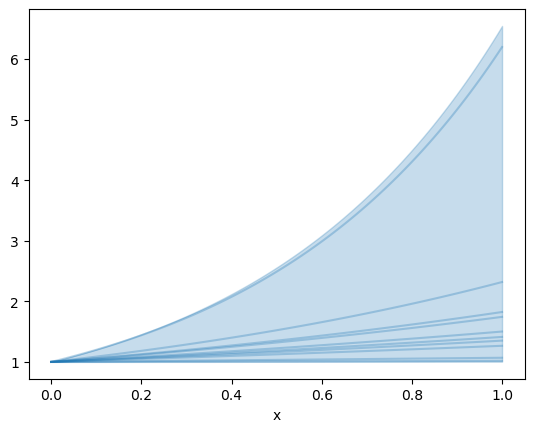

In [9]:
from pymc_marketing.mmm import SaturationTransformation


def exponential_returns(x, b, *, dim=None):  # Accept dim, ignore it for elementwise ops
    x = ptx.as_xtensor(x)
    b = ptx.as_xtensor(b)
    return ptx.math.exp(b * x)


class ExponentialReturns(SaturationTransformation):
    """Exponential "Saturation"."""

    lookup_name = "exponential_returns"
    function = exponential_returns
    default_priors = {"b": Prior("HalfNormal")}


# It works the same as before for sampling and plotting
saturation = ExponentialReturns()
prior = saturation.sample_prior()
curve = saturation.sample_curve(prior)
saturation.plot_curve(curve);

Applying the saturation inside a model now uses `core_dim` instead of the deprecated `dims` parameter. For elementwise saturations, `core_dim` has no effect but is still passed by the framework:

In [10]:
coords = {
    "channel": ["TV", "Radio", "Digital"],
    "date": range(10),
}

x = DataArray(
    np.random.default_rng(0).normal(size=(10, 3)),
    dims=("date", "channel"),
)

with pm.Model(coords=coords):
    result = saturation.apply(x, core_dim="date")

    print(f"Result type: {type(result).__name__}")
    print(f"Result dims: {result.dims}")

Result type: XTensorVariable
Result dims: ('date', 'channel')


### Custom Adstock Transformations

Adstock functions operate along a time dimension (convolution). The key change: instead of assuming a numerical axis (defaulting to 0), the function receives `dim` by name and must forward it to the underlying convolution function. There's no default:

Sampling: [adstock_alpha]
Sampling: []


Output()

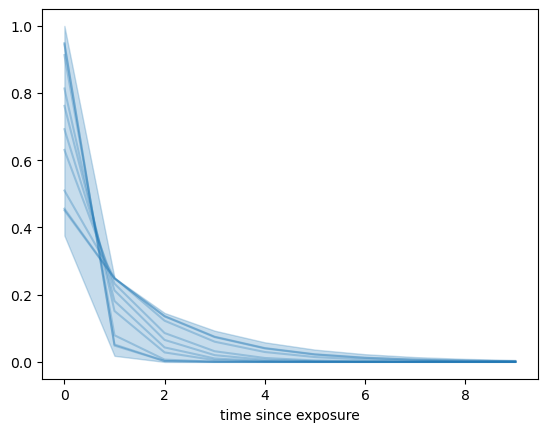

In [11]:
from pymc_marketing.mmm import AdstockTransformation
from pymc_marketing.mmm.transformers import geometric_adstock


class MyAdstock(AdstockTransformation):
    """Reinventing the wheel."""

    lookup_name = "my_adstock"

    def function(self, x, alpha, *, dim: str):
        """It's just geometric_adstock."""
        return geometric_adstock(
            x,
            alpha=alpha,
            l_max=self.l_max,
            normalize=self.normalize,
            mode=self.mode,
            dim=dim,
        )

    default_priors = {"alpha": Prior("Beta", alpha=1, beta=3)}


# Sampling and plotting still works the same
rng = np.random.default_rng(0)
adstock = MyAdstock(l_max=10)
prior = adstock.sample_prior(random_seed=rng)
curve = adstock.sample_curve(prior)
adstock.plot_curve(curve, random_seed=rng);

When applying adstock inside a model, `core_dim` tells the convolution which dimension to operate along:

In [12]:
with pm.Model(coords=coords):
    result = adstock.apply(x, core_dim="date")

    print(f"Result type: {type(result).__name__}")
    print(f"Result dims: {result.dims}")

Result type: XTensorVariable
Result dims: ('channel', 'date')


### Custom Model Building with `pymc.dims` and `xtensor`

If you build custom PyMC models that extend MMM, the key changes are:

1. Use `pymc.dims` (`pmd`) instead of `pymc` (`pm`) for dimension-aware distributions and data
2. Use `pytensor.xtensor` (`ptx`) instead of `pytensor.tensor` (`pt`) for math operations
3. Wrap raw data with `as_xtensor(data, dims=(...))` to give it named dimensions

In [13]:
coords = {
    "date": range(52),
    "channel": ["TV", "Radio"],
}

with pm.Model(coords=coords):
    # pmd creates XTensorVariables with named dims
    channel_data = pmd.Data(
        "channel_data",
        np.random.default_rng(0).normal(size=(52, 2)),
        dims=("date", "channel"),
    )
    intercept = pmd.Normal("intercept", mu=0, sigma=1)
    beta = pmd.HalfNormal("beta", sigma=1, dims="channel")

    # xtensor math - operations are dimension-aware, no axis= needed
    contribution = beta * channel_data
    total = intercept + contribution.sum(dim="channel")

    # Replace NaNs using xtensor math
    total_clean = ptx.math.switch(ptx.math.isnan(total), 0.0, total)

    mu = pmd.Deterministic("mu", total_clean, dims="date")

    print(f"mu dims: {mu.dims}")
    print(f"beta dims: {beta.dims}")
    print(f"contribution dims: {contribution.dims}")

mu dims: ('date',)
beta dims: ('channel',)
contribution dims: ('channel', 'date')


## Quick API Reference

| Old | New |
|-----|-----|
| `import pymc as pm` | `import pymc.dims as pmd` (for dimension-aware code) |
| `pm.Data(...)` | `pmd.Data(...)` |
| `pm.Normal(...)` | `pmd.Normal(...)` |
| `pm.Deterministic(...)` | `pmd.Deterministic(...)` |
| `import pytensor.tensor as pt` | `import pytensor.xtensor as ptx` |
| `pt.switch(...)` | `ptx.math.switch(...)` |
| `TensorVariable` | `XTensorVariable` |
| `prior.create_variable(name)` | `prior.create_variable(name, xdist=True)` |
| `transformation.apply(x, dims=...)` | `transformation.apply(x, core_dim=...)` |
| `batched_convolution(x, w, axis=0)` | `batched_convolution(x, w, dim="date", kernel_dim="lag")` |
| `def function(self, x, alpha)` | `def function(self, x, alpha, *, dim=None)` |
| `Prior("Normal", mu=np.array([...]))` | `Prior("Normal", mu=DataArray([...], dims="channel"))` |

## Further Reading

- [`pymc.dims` documentation](https://www.pymc.io/projects/docs/en/latest/learn/core_notebooks/dims_module.html) — dimension-aware model building in PyMC
- [`xtensor` documentation](https://pytensor.readthedocs.io/en/latest/library/xtensor/index.html) — PyTensor's named-dimension tensor operations

In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing

Last updated: Fri Mar 13 2026

Python implementation: CPython
Python version       : 3.12.8
IPython version      : 8.31.0

pymc_marketing: 0.18.2

pymc_extras   : 0.9.3
pandas        : 2.2.3
pytensor      : 2.38.2
pymc          : 5.28.2
numpy         : 2.2.6
pymc_marketing: 0.18.2
xarray        : 2026.2.0

Watermark: 2.5.0

